In [ ]:
import torch
print("Gpu avilable",torch.cuda.is_available())
print("GPU name",torch.cuda.get_device_name(0))

Gpu avilable True
GPU name Tesla T4


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/image"

print("Folders in dataset:", os.listdir(dataset_path))  # Should show ['Fake', 'Original']

Folders in dataset: ['fake', 'original']


In [ ]:
import os

# Define the paths for the fake and original image folders
fake_path = os.path.join(dataset_path, "fake")
original_path = os.path.join(dataset_path, "original")

# Count the number of images in each folder
num_fake = len(os.listdir(fake_path))
num_original = len(os.listdir(original_path))

# Print the count of images in each category
print(f"Fake images: {num_fake}")
print(f"Original images: {num_original}")


Fake images: 495
Original images: 495


In [ ]:
from torch.utils.data import Dataset
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms

# Define Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Function to remove edges
def remove_edges(image, threshold=10):
    image_np = np.array(image)
    is_grayscale = len(image_np.shape) == 2 or image_np.shape[2] == 1

    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY) if not is_grayscale else image_np
    _, binary = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, contours, -1, (255), thickness=cv2.FILLED)

    cleaned = cv2.bitwise_and(image_np, image_np, mask=mask)
    if not is_grayscale:
        cleaned = cv2.cvtColor(cleaned, cv2.COLOR_GRAY2RGB)

    return Image.fromarray(cleaned)

# Custom dataset with manual path definition
class SmartphoneDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        path = self.image_paths[index]
        label = self.labels[index]

        image = Image.open(path).convert("RGB")
        image = remove_edges(image)  # Remove edges before transformation

        if self.transform:
            image = self.transform(image)

        return image, label

# Get image paths and labels
fake_images = [os.path.join(fake_path, img) for img in os.listdir(fake_path)]
original_images = [os.path.join(original_path, img) for img in os.listdir(original_path)]

image_paths = fake_images + original_images
labels = [0] * len(fake_images) + [1] * len(original_images)  # 0 for fake, 1 for original

# Load dataset
dataset = SmartphoneDataset(image_paths, labels, transform=transform)



FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/image/fake'

In [ ]:
import cv2
# checking for corrupt or unreadable images

def check_corrupt_images(folder_path):
    corrupt_files = []
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is None:
            corrupt_files.append(file)
    return corrupt_files

fake_corrupt = check_corrupt_images(fake_path)
original_corrupt = check_corrupt_images(original_path)

print("Corrupt Fake Images:", fake_corrupt)
print("Corrupt Original Images:", original_corrupt)


Corrupt Fake Images: []
Corrupt Original Images: []


In [ ]:
!pip install imgaug

In [ ]:
import os
import cv2
import numpy as np
import random
import imgaug.augmenters as iaa
from google.colab import files
from tqdm import tqdm  # Progress bar for augmentation


In [ ]:
# Your dataset's actual paths
fake_path = "/content/drive/MyDrive/smartphone_classification/fake"
original_path = "/content/drive/MyDrive/smartphone_classification/original"

# Paths to save augmented images
augmented_fake_path = "/content/drive/MyDrive/smartphone_classification/Augmented_Fake"
augmented_original_path = "/content/drive/MyDrive/smartphone_classification/Augmented_Original"

# Run augmentation
augment_images(fake_path, augmented_fake_path, num_augmented=10)
augment_images(original_path, augmented_original_path, num_augmented=10)



def augment_images(input_folder, output_folder, num_augmented=10):
    """
    Applies augmentation to images in the input_folder and saves them to output_folder.

    - num_augmented: How many augmented versions per image.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Define augmentations
    seq = iaa.Sequential([
        iaa.Affine(rotate=(-15, 15)),  # Rotate randomly between -15° to 15°
        iaa.Fliplr(0.5),  # Flip 50% of images horizontally
        iaa.Multiply((0.8, 1.2)),  # Adjust brightness randomly (80% to 120%)
        iaa.AdditiveGaussianNoise(scale=(0, 0.05*255))  # Add slight Gaussian noise
    ])

    # Process each image
    for img_name in tqdm(os.listdir(input_folder), desc=f"Augmenting {input_folder}"):
        img_path = os.path.join(input_folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"⚠ Warning: Unable to read {img_name}. Skipping...")
            continue  # Skip this image

        for i in range(num_augmented):
            # Apply augmentation
            augmented_img = seq.augment_image(img)

            # Save augmented image
            new_filename = f"{os.path.splitext(img_name)[0]}_aug_{i}.jpg"
            new_filepath = os.path.join(output_folder, new_filename)
            cv2.imwrite(new_filepath, augmented_img)

        print(f"✅ Processed {img_name}")

    print(f"\n🎉 Augmentation complete! Augmented images saved in: {output_folder}")



Augmenting /content/drive/MyDrive/smartphone_classification/fake:   2%|▏         | 1/45 [00:00<00:12,  3.57it/s]

✅ Processed Galaxy_S20plus.png


Augmenting /content/drive/MyDrive/smartphone_classification/fake:   7%|▋         | 3/45 [00:01<00:19,  2.11it/s]

✅ Processed galaxya50internal.png
✅ Processed galaxya54internal.png


Augmenting /content/drive/MyDrive/smartphone_classification/fake:   9%|▉         | 4/45 [00:02<00:20,  2.03it/s]

...

✅ Processed original iphone 6 non xray.jpg


Augmenting /content/drive/MyDrive/smartphone_classification/original:  98%|█████████▊| 44/45 [00:16<00:00,  4.08it/s]

✅ Processed original iphone 5 non xray.jpg


Augmenting /content/drive/MyDrive/smartphone_classification/original: 100%|██████████| 45/45 [00:16<00:00,  2.70it/s]

✅ Processed original iphone 5s non xray.jpg

🎉 Augmentation complete! Augmented images saved in: /content/drive/MyDrive/smartphone_classification/Augmented_Original


In [ ]:
# 📦 Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import KFold
from PIL import Image
import numpy as np
from collections import Counter

# 🔧 Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 🔁 Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# 🧾 Custom dataset with RGB conversion
class UnifiedDataset(ImageFolder):
    def __getitem__(self, index):
        path, label = self.samples[index]
        image = Image.open(path).convert("RGB")
        image = transform(image)
        return image, label

# 📂 Load dataset
dataset_path = "/content/drive/MyDrive/image"
dataset = UnifiedDataset(root=dataset_path)

# 🧪 Split 80% train_val, 20% test (stratified-like)
num_total = len(dataset)
num_test = int(0.2 * num_total)
num_train_val = num_total - num_test
train_val_dataset, test_dataset = random_split(dataset, [num_train_val, num_test], generator=torch.Generator().manual_seed(42))

print(f"Total: {num_total}, Train+Val: {len(train_val_dataset)}, Test: {len(test_dataset)}")

# ⚖️ Compute class weights for weighted loss
train_val_labels = [dataset[i][1] for i in train_val_dataset.indices]
label_counter = Counter(train_val_labels)
num_classes = len(dataset.classes)
class_weights = [len(train_val_dataset) / (num_classes * label_counter[c]) for c in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class distribution (Train+Val): {label_counter}")
print(f"Class weights: {class_weights}")


Using device: cuda
Total: 990, Train+Val: 792, Test: 198
Class distribution (Train+Val): Counter({0: 406, 1: 386})
Class weights: [0.9753694581280788, 1.0259067357512954]


# DENSENET

In [ ]:
pip install bayesian-optimization

In [ ]:
# 📦 Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np
from collections import Counter
from bayes_opt import BayesianOptimization
from sklearn.metrics import confusion_matrix, classification_report

# 🔧 Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 🔁 Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# 🧾 Custom dataset with RGB conversion
class UnifiedDataset(ImageFolder):
    def __getitem__(self, index):
        path, label = self.samples[index]
        image = Image.open(path).convert("RGB")
        image = transform(image)
        return image, label


# 📂 Load dataset
dataset_path = "/content/drive/MyDrive/image"
dataset = UnifiedDataset(root=dataset_path)

# 🧪 Split 80% train_val, 20% test (stratified-like)
num_total = len(dataset)
num_test = int(0.2 * num_total)
num_train_val = num_total - num_test
train_val_dataset, test_dataset = random_split(dataset, [num_train_val, num_test], generator=torch.Generator().manual_seed(42))

print(f"Total: {num_total}, Train+Val: {len(train_val_dataset)}, Test: {len(test_dataset)}")

# ⚖️ Compute class weights for weighted loss
train_val_labels = [dataset[i][1] for i in train_val_dataset.indices]
label_counter = Counter(train_val_labels)
num_classes = len(dataset.classes)
class_weights = [len(train_val_dataset) / (num_classes * label_counter[c]) for c in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class distribution (Train+Val): {label_counter}")
print(f"Class weights: {class_weights}")


# 🏗️ Load DenseNet model
model = models.densenet121(pretrained=True)

# Modify the classifier for dataset
model.classifier = nn.Linear(model.classifier.in_features, num_classes)

# Move to device
model = model.to(device)



# 🎯 Function to optimize
def train_eval_model(lr, batch_size, weight_decay):
    lr = max(lr, 1e-6)
    batch_size = int(batch_size)
    weight_decay = max(weight_decay, 1e-6)

    train_loader = DataLoader(train_val_dataset, batch_size=batch_size, shuffle=True)

    # Load model
    model = models.densenet121(pretrained=True)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    model.to(device)

    # Define optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

    # Quick training loop (few epochs for evaluation)
    model.train()
    total_correct, total_samples = 0, 0
    for epoch in range(3):  # Few epochs for Bayesian tuning
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Compute accuracy
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    val_accuracy = total_correct / total_samples
    return val_accuracy

# 📌 Bayesian Optimization Setup
pbounds = {
    'lr': (1e-5, 1e-3),
    'batch_size': (16, 128),
    'weight_decay': (1e-5, 1e-3),
}

optimizer = BayesianOptimization(f=train_eval_model, pbounds=pbounds, random_state=42)
optimizer.maximize(init_points=5, n_iter=10)

print("Best parameters found:", optimizer.max)




# 🔧 Best hyperparameters
best_params = optimizer.max['params']
lr_best, batch_size_best, weight_decay_best = best_params["lr"], int(best_params["batch_size"]), best_params["weight_decay"]

# Create DataLoader with optimized batch size
train_loader = DataLoader(train_val_dataset, batch_size=batch_size_best, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=lr_best, weight_decay=weight_decay_best)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

# 🚀 Training loop
model.train()
num_epochs = 10  # Adjust as needed
for epoch in range(num_epochs):
    total_correct, total_samples = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Compute accuracy
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    print(f"Epoch {epoch+1}/{num_epochs}, Accuracy: {total_correct/total_samples:.4f}")



# 🧐 Evaluation Function
def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=dataset.classes)

    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", report)

# Run evaluation
evaluate_model(model, test_loader)




Using device: cuda
Total: 990, Train+Val: 792, Test: 198
Class distribution (Train+Val): Counter({0: 406, 1: 386})
Class weights: [0.9753694581280788, 1.0259067357512954]
|   iter    |  target   | batch_... |    lr     | weight... |
-------------------------------------------------------------
| 1         | 0.4832    | 57.95     | 0.0009512 | 0.0007347 |
| 2         | 0.7037    | 83.05     | 0.0001645 | 0.0001644 |
| 3         | 0.5093    | 22.51     | 0.0008675 | 0.0006051 |
| 4         | 0.6801    | 95.3      | 3.038e-05 | 0.0009702 |
| 5         | 0.6915    | 109.2     | 0.0002202 | 0.00019   |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 6         | 0.7029    | 128.0     | 0.0001798 | 0.0007738 |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 7         | 0.6406    | 81.59     | 0.0003051 | 0.0001156 |


...

| 13        | 0.5362    | 90.47     | 0.0009779 | 0.000382  |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 14        | 0.7226    | 99.55     | 0.0001026 | 0.0004762 |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 15        | 0.7155    | 70.37     | 0.0001398 | 0.0004214 |
Best parameters found: {'target': np.float64(0.7264309764309764), 'params': {'batch_size': np.float64(85.8904528442513), 'lr': np.float64(0.00013956479694381588), 'weight_decay': np.float64(0.00015478389274117043)}}
Epoch 1/10, Accuracy: 0.4836
Epoch 2/10, Accuracy: 0.7626
Epoch 3/10, Accuracy: 0.8712
Epoch 4/10, Accuracy: 0.9255
Epoch 5/10, Accuracy: 0.9520
Epoch 6/10, Accuracy: 0.9722
Epoch 7/10, Accuracy: 0.9747
Epoch 8/10, Accuracy: 0.9672
Epoch 9/10, Accuracy: 0.9672
Epoch 10/10, Accuracy: 0.9659
Confusion Matrix:
 [[47 42]
 [40 69]]
Classification Report:
               precision    recall  f1-score   support

        fake       0.54      0.53      0.53        89
    original       0.62      0.63      0.63       109

    accuracy                           0.59       198
   macro avg       0.58      0.58      0.58       198
weighted avg       0.59      0.59      0.59       198



#RESNET

In [ ]:
# 📦 Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np
from collections import Counter
from bayes_opt import BayesianOptimization
from sklearn.metrics import confusion_matrix, classification_report

# 🔧 Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 🔁 Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# 🧾 Custom dataset with RGB conversion
class UnifiedDataset(ImageFolder):
    def __getitem__(self, index):
        path, label = self.samples[index]
        image = Image.open(path).convert("RGB")
        image = transform(image)
        return image, label

# 📂 Load dataset
dataset_path = "/content/drive/MyDrive/image"
dataset = UnifiedDataset(root=dataset_path)

# 🧪 Split 80% train_val, 20% test (stratified-like)
num_total = len(dataset)
num_test = int(0.2 * num_total)
num_train_val = num_total - num_test
train_val_dataset, test_dataset = random_split(dataset, [num_train_val, num_test], generator=torch.Generator().manual_seed(42))

print(f"Total: {num_total}, Train+Val: {len(train_val_dataset)}, Test: {len(test_dataset)}")

# ⚖️ Compute class weights for weighted loss
train_val_labels = [dataset[i][1] for i in train_val_dataset.indices]
label_counter = Counter(train_val_labels)
num_classes = len(dataset.classes)
class_weights = [len(train_val_dataset) / (num_classes * label_counter[c]) for c in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class distribution (Train+Val): {label_counter}")
print(f"Class weights: {class_weights}")

# 🏗️ Load ResNet model
model = models.resnet50(pretrained=True)

# Modify the final layer for dataset
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move to device
model = model.to(device)


# 🎯 Function to optimize
def train_eval_model(lr, batch_size, weight_decay):
    lr = max(lr, 1e-6)
    batch_size = int(batch_size)
    weight_decay = max(weight_decay, 1e-6)

    train_loader = DataLoader(train_val_dataset, batch_size=batch_size, shuffle=True)

    # Load model
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.to(device)

    # Define optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

    # Quick training loop (few epochs for evaluation)
    model.train()
    total_correct, total_samples = 0, 0
    for epoch in range(3):  # Few epochs for Bayesian tuning
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Compute accuracy
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    val_accuracy = total_correct / total_samples
    return val_accuracy

# 📌 Bayesian Optimization Setup
pbounds = {
    'lr': (1e-5, 1e-3),
    'batch_size': (16, 128),
    'weight_decay': (1e-5, 1e-3),
}

optimizer = BayesianOptimization(f=train_eval_model, pbounds=pbounds, random_state=42)
optimizer.maximize(init_points=5, n_iter=10)

print("Best parameters found:", optimizer.max)


# 🔧 Best hyperparameters
best_params = optimizer.max['params']
lr_best, batch_size_best, weight_decay_best = best_params["lr"], int(best_params["batch_size"]), best_params["weight_decay"]

# Create DataLoader with optimized batch size
train_loader = DataLoader(train_val_dataset, batch_size=batch_size_best, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=lr_best, weight_decay=weight_decay_best)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

# 🚀 Training loop
model.train()
num_epochs = 10  # Adjust as needed
for epoch in range(num_epochs):
    total_correct, total_samples = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Compute accuracy
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    print(f"Epoch {epoch+1}/{num_epochs}, Accuracy: {total_correct/total_samples:.4f}")


# 🧐 Evaluation Function
def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=dataset.classes)

    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", report)

# Run evaluation
evaluate_model(model, test_loader)

Using device: cuda
Total: 990, Train+Val: 792, Test: 198
Class distribution (Train+Val): Counter({0: 406, 1: 386})
Class weights: [0.9753694581280788, 1.0259067357512954]


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


|   iter    |  target   | batch_... |    lr     | weight... |
-------------------------------------------------------------
| 1         | 0.4857    | 57.95     | 0.0009512 | 0.0007347 |
| 2         | 0.6793    | 83.05     | 0.0001645 | 0.0001644 |
| 3         | 0.5215    | 22.51     | 0.0008675 | 0.0006051 |
| 4         | 0.737     | 95.3      | 3.038e-05 | 0.0009702 |
| 5         | 0.6284    | 109.2     | 0.0002202 | 0.00019   |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 6         | 0.6658    | 128.0     | 0.0001798 | 0.0007738 |


...

| 13        | 0.5114    | 61.14     | 0.0008423 | 0.00076   |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 14        | 0.5955    | 84.36     | 0.0002292 | 0.0009764 |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 15        | 0.5       | 20.58     | 0.000494  | 0.0005957 |
Best parameters found: {'target': np.float64(0.7369528619528619), 'params': {'batch_size': np.float64(95.3041287131571), 'lr': np.float64(3.0378649352844424e-05), 'weight_decay': np.float64(0.0009702107536403744)}}
Epoch 1/10, Accuracy: 0.4836
Epoch 2/10, Accuracy: 0.8207
Epoch 3/10, Accuracy: 0.9116
Epoch 4/10, Accuracy: 0.9470
Epoch 5/10, Accuracy: 0.9583
Epoch 6/10, Accuracy: 0.9697
Epoch 7/10, Accuracy: 0.9621
Epoch 8/10, Accuracy: 0.9760
Epoch 9/10, Accuracy: 0.9710
Epoch 10/10, Accuracy: 0.9848
Confusion Matrix:
 [[41 48]
 [50 59]]
Classification Report:
               precision    recall  f1-score   support

        fake       0.45      0.46      0.46        89
    original       0.55      0.54      0.55       109

    accuracy                           0.51       198
   macro avg       0.50      0.50      0.50       198
weighted avg       0.51      0.51      0.51       198



#EFFICIENTNET

In [ ]:
!pip install bayesian-optimization




In [ ]:
# 📦 Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np
from collections import Counter
from bayes_opt import BayesianOptimization
from sklearn.metrics import confusion_matrix, classification_report

# 🔧 Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 🔁 Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # EfficientNet works well with 224x224 images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])

# 🧾 Custom dataset with RGB conversion
class UnifiedDataset(ImageFolder):
    def __getitem__(self, index):
        path, label = self.samples[index]
        image = Image.open(path).convert("RGB")
        image = transform(image)
        return image, label

# 📂 Load dataset
dataset_path = "/content/drive/MyDrive/image"
dataset = UnifiedDataset(root=dataset_path)

# 🧪 Split 80% train_val, 20% test (stratified-like)
num_total = len(dataset)
num_test = int(0.2 * num_total)
num_train_val = num_total - num_test
train_val_dataset, test_dataset = random_split(dataset, [num_train_val, num_test], generator=torch.Generator().manual_seed(42))

print(f"Total: {num_total}, Train+Val: {len(train_val_dataset)}, Test: {len(test_dataset)}")

# ⚖️ Compute class weights for weighted loss (penalizing rare classes)
train_val_labels = [dataset[i][1] for i in train_val_dataset.indices]
label_counter = Counter(train_val_labels)
num_classes = len(dataset.classes)
class_weights = [len(train_val_dataset) / (num_classes * label_counter[c]) for c in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class distribution (Train+Val): {label_counter}")
print(f"Class weights: {class_weights}")

# 🏗️ Load EfficientNet model (B0 variant)
model = models.efficientnet_b0(pretrained=True)

# Modify classifier for dataset (EfficientNet uses 'classifier')
model.classifier = nn.Linear(model.classifier[1].in_features, num_classes)

# Move to device
model = model.to(device)

# 🎯 Function to optimize
def train_eval_model(lr, batch_size, weight_decay):
    lr = max(lr, 1e-6)
    batch_size = int(batch_size)
    weight_decay = max(weight_decay, 1e-6)

    train_loader = DataLoader(train_val_dataset, batch_size=batch_size, shuffle=True)

    # Load model
    model = models.efficientnet_b0(pretrained=True)
    model.classifier = nn.Linear(model.classifier[1].in_features, num_classes)
    model.to(device)

    # Define optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

    # Quick training loop (few epochs for evaluation)
    model.train()
    total_correct, total_samples = 0, 0
    for epoch in range(3):  # Few epochs for Bayesian tuning
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Compute accuracy
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    val_accuracy = total_correct / total_samples
    return val_accuracy

# 📌 Bayesian Optimization Setup
pbounds = {
    'lr': (1e-5, 1e-3),
    'batch_size': (16, 128),
    'weight_decay': (1e-5, 1e-3),
}

optimizer = BayesianOptimization(f=train_eval_model, pbounds=pbounds, random_state=42)
optimizer.maximize(init_points=5, n_iter=10)

print("Best parameters found:", optimizer.max)

# 🔧 Best hyperparameters
best_params = optimizer.max['params']
lr_best, batch_size_best, weight_decay_best = best_params["lr"], int(best_params["batch_size"]), best_params["weight_decay"]

# Create DataLoader with optimized batch size
train_loader = DataLoader(train_val_dataset, batch_size=batch_size_best, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=lr_best, weight_decay=weight_decay_best)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

# 🚀 Training loop
model.train()
num_epochs = 10  # Adjust as needed
for epoch in range(num_epochs):
    total_correct, total_samples = 0, 0
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Compute metrics
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)
    epoch_acc = total_correct / total_samples
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

# 🧐 Evaluation Function
def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = test_loss / len(dataloader.dataset)
    test_acc = correct / len(dataloader.dataset)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=dataset.classes)

    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", report)

# Run evaluation
evaluate_model(model, test_loader)

# 💾 Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names': dataset.classes,
}, 'efficientnet_model.pth')

Using device: cuda
Total: 990, Train+Val: 792, Test: 198
Class distribution (Train+Val): Counter({0: 406, 1: 386})
Class weights: [0.9753694581280788, 1.0259067357512954]
|   iter    |  target   | batch_... |    lr     | weight... |
-------------------------------------------------------------


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 1         | 0.6494    | 57.95     | 0.0009512 | 0.0007347 |
| 2         | 0.6612    | 83.05     | 0.0001645 | 0.0001644 |
| 3         | 0.5918    | 22.51     | 0.0008675 | 0.0006051 |
| 4         | 0.5518    | 95.3      | 3.038e-05 | 0.0009702 |
| 5         | 0.6772    | 109.2     | 0.0002202 | 0.00019   |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 6         | 0.654     | 109.3     | 0.00072   | 0.0004842 |


...

| 13        | 0.6591    | 83.91     | 0.000746  | 0.000275  |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 14        | 0.6818    | 84.21     | 0.0004741 | 0.0005363 |


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


| 15        | 0.649     | 84.41     | 0.0009562 | 0.0006907 |
Best parameters found: {'target': np.float64(0.6818181818181818), 'params': {'batch_size': np.float64(84.20528845889478), 'lr': np.float64(0.0004740722446016528), 'weight_decay': np.float64(0.0005362555466819422)}}
Epoch 1/10, Loss: 0.7268, Accuracy: 0.4861
Epoch 2/10, Loss: 0.5716, Accuracy: 0.7424
Epoch 3/10, Loss: 0.4093, Accuracy: 0.8333
Epoch 4/10, Loss: 0.2636, Accuracy: 0.8965
Epoch 5/10, Loss: 0.2164, Accuracy: 0.9154
Epoch 6/10, Loss: 0.1585, Accuracy: 0.9331
Epoch 7/10, Loss: 0.1366, Accuracy: 0.9533
Epoch 8/10, Loss: 0.1269, Accuracy: 0.9545
Epoch 9/10, Loss: 0.1313, Accuracy: 0.9533
Epoch 10/10, Loss: 0.0976, Accuracy: 0.9646
Test Loss: 0.7171, Test Accuracy: 0.7929
Confusion Matrix:
 [[71 18]
 [23 86]]
Classification Report:
               precision    recall  f1-score   support

        fake       0.76      0.80      0.78        89
    original       0.83      0.79      0.81       109

    accuracy             

#ENSEMBLE (SOFT MAX & STACKING)

In [ ]:
import os
import shutil

# Define directories to clear
save_directory = '/content/drive/MyDrive/trained_ensemble_models'
log_directory = '/content/drive/MyDrive/model_logs'

def delete_existing_files(directory):
    if os.path.exists(directory):
        shutil.rmtree(directory)  # Remove entire directory
        os.makedirs(directory)  # Recreate empty directory
        print(f"✅ Cleared: {directory}")
    else:
        print(f"🔹 Directory not found, skipping: {directory}")

# Clear previous saved models and logs
delete_existing_files(save_directory)
delete_existing_files(log_directory)

print("\n🚀 Ready to start training from scratch!")

✅ Cleared: /content/drive/MyDrive/trained_ensemble_models
✅ Cleared: /content/drive/MyDrive/model_logs

🚀 Ready to start training from scratch!


In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression # Meta-model for Stacking
from sklearn.preprocessing import StandardScaler # Optional but good practice for meta-features
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Ensure reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Custom dataset with RGB conversion
class UnifiedDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        path = self.image_paths[index]
        label = self.labels[index]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

Using device: cuda


In [ ]:
# Load dataset paths and labels
dataset_path = "/content/drive/MyDrive/image" # Make sure this path is correct
full_dataset_info = ImageFolder(root=dataset_path)
image_paths = [item[0] for item in full_dataset_info.samples]
labels = [item[1] for item in full_dataset_info.samples]
class_names = full_dataset_info.classes
num_classes = len(class_names)

print(f"Found {len(image_paths)} images with {num_classes} classes: {class_names}")
print(f"Overall Class distribution: {Counter(labels)}")

# Stratified Data Splitting (80/20 train+val/test, then 80/20 train/val)
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.20, stratify=labels, random_state=42
)

# Split the 80% train+val data into 80% train and 20% val
# This results in a 64% train, 16% val split of the original dataset
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.20, stratify=train_val_labels, random_state=42
)

# Create UnifiedDataset instances
train_dataset = UnifiedDataset(train_paths, train_labels, transform=transform)
val_dataset = UnifiedDataset(val_paths, val_labels, transform=transform)
test_dataset = UnifiedDataset(test_paths, test_labels, transform=transform)

print(f"Total: {len(image_paths)}, Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Train class distribution: {Counter(train_labels)}")
print(f"Val class distribution: {Counter(val_labels)}")
print(f"Test class distribution: {Counter(test_labels)}")

# Compute class weights for weighted loss (based on training data)
train_label_counter = Counter(train_labels)
class_weights = [len(train_dataset) / (num_classes * train_label_counter.get(c, 1e-9)) for c in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class weights (based on training data): {class_weights}")

Found 990 images with 2 classes: ['fake', 'original']
Overall Class distribution: Counter({0: 495, 1: 495})
Total: 990, Train: 633, Val: 159, Test: 198
Train class distribution: Counter({1: 317, 0: 316})
Val class distribution: Counter({0: 80, 1: 79})
Test class distribution: Counter({0: 99, 1: 99})
Class weights (based on training data): [1.0015822784810127, 0.998422712933754]


In [ ]:
# Dictionary to store model information
model_info = {}

# Function to build model based on architecture name
def build_model(architecture_name, num_classes):
    if architecture_name not in model_info:
         model_info[architecture_name] = {}

    # Use weights parameter for current torchvision versions
    if architecture_name == 'efficientnet_b0':
        try:
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        except Exception as e:
             print(f"Could not load EfficientNet_B0_Weights.IMAGENET1K_V1, trying pretrained=True fallback: {e}")
             model = models.efficientnet_b0(pretrained=True)

        in_features = model.classifier[1].in_features
        model.classifier = nn.Linear(in_features, num_classes)

        model_info[architecture_name]['parameters'] = sum(p.numel() for p in model.parameters())
        model_info[architecture_name]['trainable_parameters'] = sum(p.numel() for p in model.parameters() if p.requires_grad)
        model_info[architecture_name]['architecture_details'] = {
            'input_size': 224, 'classifier_in_features': in_features, 'base_architecture': 'EfficientNet B0'
        }

    elif architecture_name == 'densenet121':
        try:
            model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        except Exception as e:
             print(f"Could not load DenseNet121_Weights.IMAGENET1K_V1, trying pretrained=True fallback: {e}")
             model = models.densenet121(pretrained=True)

        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

        model_info[architecture_name]['parameters'] = sum(p.numel() for p in model.parameters())
        model_info[architecture_name]['trainable_parameters'] = sum(p.numel() for p in model.parameters() if p.requires_grad)
        model_info[architecture_name]['architecture_details'] = {
            'input_size': 224, 'classifier_in_features': in_features, 'base_architecture': 'DenseNet 121'
        }

    elif architecture_name == 'resnet50':
        try:
             model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        except Exception as e:
             print(f"Could not load ResNet50_Weights.IMAGENET1K_V1, trying pretrained=True fallback: {e}")
             model = models.resnet50(pretrained=True)

        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

        model_info[architecture_name]['parameters'] = sum(p.numel() for p in model.parameters())
        model_info[architecture_name]['trainable_parameters'] = sum(p.numel() for p in model.parameters() if p.requires_grad)
        model_info[architecture_name]['architecture_details'] = {
            'input_size': 224, 'classifier_in_features': in_features, 'base_architecture': 'ResNet 50'
        }

    else:
        raise ValueError(f"Unsupported architecture: {architecture_name}")

    return model

# Function to train and save a single model
def train_and_save_model(model_name, train_dataset, val_dataset, hyperparameters, class_weights_tensor, save_dir):
    print(f"\n--- Training {model_name} ---")
    set_seed(42)

    model = build_model(model_name, num_classes).to(device)

    train_loader = DataLoader(train_dataset, batch_size=int(hyperparameters['batch_size']), shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    optimizer = optim.Adam(model.parameters(), lr=hyperparameters['lr'], weight_decay=hyperparameters['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

    model_info[model_name]['hyperparameters'] = hyperparameters
    model_info[model_name]['training_history'] = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    model_info[model_name]['best_epoch'] = 0
    model_info[model_name]['best_val_accuracy'] = 0.0

    num_epochs = 20
    best_val_accuracy = 0.0
    best_epoch_idx = 0

    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = correct_train / total_train

        model.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        epoch_val_loss = val_loss / len(val_dataset)
        epoch_val_acc = correct_val / total_val

        model_info[model_name]['training_history']['train_loss'].append(epoch_loss)
        model_info[model_name]['training_history']['train_acc'].append(epoch_acc)
        model_info[model_name]['training_history']['val_loss'].append(epoch_val_loss)
        model_info[model_name]['training_history']['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        if epoch_val_acc >= best_val_accuracy:
            best_val_accuracy = epoch_val_acc
            best_epoch_idx = epoch
            model_filename = os.path.join(save_dir, f'{model_name}_best_model.pth')
            torch.save({'model_state_dict': model.state_dict(), 'val_accuracy': best_val_accuracy, 'class_names': class_names, 'epoch': epoch + 1, 'hyperparameters': hyperparameters}, model_filename)
            print(f"Saved best model for {model_name} with Val Acc: {best_val_accuracy:.4f}")
            model_info[model_name]['best_epoch'] = epoch + 1
            model_info[model_name]['best_val_accuracy'] = best_val_accuracy

    print(f"--- Finished training {model_name}. Best Validation Accuracy: {model_info[model_name]['best_val_accuracy']:.4f} at Epoch {model_info[model_name]['best_epoch']} ---")
    return model_info[model_name]['best_val_accuracy']

In [ ]:
# Define best hyperparameters for each model
best_hyperparameters = {
    'densenet121': {'batch_size': 58, 'lr': 0.0009512, 'weight_decay': 0.0007347},
    'resnet50': {'batch_size': 83, 'lr': 0.0001645, 'weight_decay': 0.0001644},
    'efficientnet_b0': {'batch_size': 84, 'lr': 0.0004741, 'weight_decay': 0.0005363},
}

# Define directory to save models
save_directory = '/content/drive/MyDrive/trained_ensemble_models'
os.makedirs(save_directory, exist_ok=True)

# Create log directory for plots and reports
log_directory = '/content/drive/MyDrive/model_logs'
os.makedirs(log_directory, exist_ok=True)

In [ ]:
# Train or Load each model
model_validation_accuracies = {}

print("\n--- Training/Loading Individual Models ---")
for model_name in best_hyperparameters.keys():
     model_info[model_name] = {} # Ensure entry exists before building/training

for model_name, hparams in best_hyperparameters.items():
    model_path = os.path.join(save_directory, f'{model_name}_best_model.pth')
    if os.path.exists(model_path):
        print(f"\nSkipping training for {model_name}. Best model already found at {model_path}")
        try:
            checkpoint = torch.load(model_path, map_location='cpu')
            model_info[model_name]['best_val_accuracy'] = checkpoint.get('val_accuracy', 'N/A')
            model_info[model_name]['best_epoch'] = checkpoint.get('epoch', 'N/A')
            model_info[model_name]['hyperparameters'] = checkpoint.get('hyperparameters', {})
            # Build model briefly to populate architecture details in model_info
            build_model(model_name, num_classes)
            model_info[model_name]['training_history'] = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []} # Add dummy history
            model_validation_accuracies[model_name] = model_info[model_name]['best_val_accuracy']
            # Ensure accuracy is a float before printing with formatting
            if isinstance(model_validation_accuracies[model_name], float):
                print(f"Loaded info for {model_name} (Val Acc: {model_validation_accuracies[model_name]:.4f})")
            else:
                print(f"Loaded info for {model_name} (Val Acc: {model_validation_accuracies[model_name]})")

        except Exception as e:
            print(f"Error loading info from existing model {model_name}: {e}. Retraining.")
            val_acc = train_and_save_model(model_name, train_dataset, val_dataset, hparams, class_weights_tensor, save_directory)
            model_validation_accuracies[model_name] = val_acc
    else:
        val_acc = train_and_save_model(model_name, train_dataset, val_dataset, hparams, class_weights_tensor, save_directory)
        model_validation_accuracies[model_name] = val_acc

print("\nValidation accuracies of trained/loaded models:")
for model_name, acc in model_validation_accuracies.items():
    # Ensure acc is a float before formatting
    if isinstance(acc, float):
        print(f"{model_name}: {acc:.4f}")
    else:
        print(f"{model_name}: {acc}")


--- Training/Loading Individual Models ---

--- Training densenet121 ---


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 156MB/s]


Starting training for 20 epochs...
Epoch 1/20, Train Loss: 0.8066, Train Acc: 0.5166, Val Loss: 6.3004, Val Acc: 0.5094
Saved best model for densenet121 with Val Acc: 0.5094
Epoch 2/20, Train Loss: 0.7369, Train Acc: 0.5403, Val Loss: 1.4346, Val Acc: 0.5031
Epoch 3/20, Train Loss: 0.6891, Train Acc: 0.5577, Val Loss: 0.7315, Val Acc: 0.5723
Saved best model for densenet121 with Val Acc: 0.5723
Epoch 4/20, Train Loss: 0.6007, Train Acc: 0.6809, Val Loss: 0.6429, Val Acc: 0.5912
Saved best model for densenet121 with Val Acc: 0.5912
Epoch 5/20, Train Loss: 0.5405, Train Acc: 0.6951, Val Loss: 2.7446, Val Acc: 0.5409
Epoch 6/20, Train Loss: 0.6080, Train Acc: 0.6793, Val Loss: 1.0334, Val Acc: 0.5912
Saved best model for densenet121 with Val Acc: 0.5912
Epoch 7/20, Train Loss: 0.5124, Train Acc: 0.7488, Val Loss: 0.6830, Val Acc: 0.6038
Saved best model for densenet121 with Val Acc: 0.6038
Epoch 8/20, Train Loss: 0.4329, Train Acc: 0.8088, Val Loss: 0.6562, Val Acc: 0.6604
Saved best mode

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


Starting training for 20 epochs...
Epoch 1/20, Train Loss: 0.7409, Train Acc: 0.5150, Val Loss: 0.8626, Val Acc: 0.4906
Saved best model for resnet50 with Val Acc: 0.4906
Epoch 2/20, Train Loss: 0.5605, Train Acc: 0.7141, Val Loss: 0.9249, Val Acc: 0.5031
Saved best model for resnet50 with Val Acc: 0.5031
Epoch 3/20, Train Loss: 0.3191, Train Acc: 0.8736, Val Loss: 1.0008, Val Acc: 0.6038
Saved best model for resnet50 with Val Acc: 0.6038
Epoch 4/20, Train Loss: 0.1838, Train Acc: 0.9305, Val Loss: 1.0527, Val Acc: 0.6667
Saved best model for resnet50 with Val Acc: 0.6667
Epoch 5/20, Train Loss: 0.1202, Train Acc: 0.9526, Val Loss: 1.2132, Val Acc: 0.6289
Epoch 6/20, Train Loss: 0.1037, Train Acc: 0.9573, Val Loss: 1.1289, Val Acc: 0.6541
Epoch 7/20, Train Loss: 0.1173, Train Acc: 0.9558, Val Loss: 0.9124, Val Acc: 0.7044
Saved best model for resnet50 with Val Acc: 0.7044
Epoch 8/20, Train Loss: 0.0867, Train Acc: 0.9668, Val Loss: 1.3798, Val Acc: 0.6226
Epoch 9/20, Train Loss: 0.0835

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


Epoch 20/20, Train Loss: 0.0108, Train Acc: 0.9953, Val Loss: 0.9600, Val Acc: 0.7547
--- Finished training resnet50. Best Validation Accuracy: 0.7610 at Epoch 19 ---

--- Training efficientnet_b0 ---


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


Starting training for 20 epochs...
Epoch 1/20, Train Loss: 0.7217, Train Acc: 0.5008, Val Loss: 0.7232, Val Acc: 0.4969
Saved best model for efficientnet_b0 with Val Acc: 0.4969
Epoch 2/20, Train Loss: 0.5484, Train Acc: 0.7504, Val Loss: 0.7465, Val Acc: 0.5597
Saved best model for efficientnet_b0 with Val Acc: 0.5597
Epoch 3/20, Train Loss: 0.4019, Train Acc: 0.8483, Val Loss: 0.8627, Val Acc: 0.5912
Saved best model for efficientnet_b0 with Val Acc: 0.5912
Epoch 4/20, Train Loss: 0.2612, Train Acc: 0.9163, Val Loss: 0.8583, Val Acc: 0.6415
Saved best model for efficientnet_b0 with Val Acc: 0.6415
Epoch 5/20, Train Loss: 0.1870, Train Acc: 0.9273, Val Loss: 1.0450, Val Acc: 0.6981
Saved best model for efficientnet_b0 with Val Acc: 0.6981
Epoch 6/20, Train Loss: 0.2211, Train Acc: 0.9084, Val Loss: 1.0591, Val Acc: 0.6667
Epoch 7/20, Train Loss: 0.1604, Train Acc: 0.9321, Val Loss: 0.9709, Val Acc: 0.6855
Epoch 8/20, Train Loss: 0.1219, Train Acc: 0.9605, Val Loss: 0.9527, Val Acc: 0.

In [ ]:
# Print detailed model information
print("\n=== DETAILED INDIVIDUAL MODEL INFORMATION ===")
for model_name in best_hyperparameters.keys():
    if model_name in model_info and model_info[model_name]:
        print(f"\n{model_name.upper()} MODEL SUMMARY:")
        print(f"Total parameters: {model_info[model_name].get('parameters', 'N/A'):,}")
        print(f"Trainable parameters: {model_info[model_name].get('trainable_parameters', 'N/A'):,}")
        print(f"Architecture details: {model_info[model_name].get('architecture_details', 'N/A')}")
        print(f"Best epoch (Val): {model_info[model_name].get('best_epoch', 'N/A')}")
        best_val_acc_print = model_info[model_name].get('best_val_accuracy', 'N/A')
        if isinstance(best_val_acc_print, float):
             print(f"Best validation accuracy: {best_val_acc_print:.4f}")
        else:
             print(f"Best validation accuracy: {best_val_acc_print}")

        print("\nHyperparameters:")
        hparams = model_info[model_name].get('hyperparameters', {})
        if hparams:
            for param, value in hparams.items():
                print(f"   - {param}: {value}")
        else:
             print("   - N/A")
    else:
        print(f"\n{model_name.upper()} MODEL SUMMARY: Information not available.")

# Plot training history for each model
print("\nGenerating training history plots...")
for model_name in best_hyperparameters.keys():
    if model_name in model_info:
        history = model_info[model_name].get('training_history', None)
        # Only plot if history is populated (i.e., model was trained, not just loaded)
        if history and history['train_loss'] and history['val_loss']:
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(history['train_loss'], label='Train Loss')
            plt.plot(history['val_loss'], label='Val Loss')
            plt.title(f'{model_name} Loss')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.legend()
            plt.subplot(1, 2, 2)
            plt.plot(history['train_acc'], label='Train Accuracy')
            plt.plot(history['val_acc'], label='Val Accuracy')
            plt.title(f'{model_name} Accuracy')
            plt.xlabel('Epochs')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.tight_layout()
            plot_filename = os.path.join(log_directory, f'{model_name}_training_history.png')
            plt.savefig(plot_filename)
            plt.close()
            print(f"Saved training history plot for {model_name} to: {plot_filename}")
        else:
            print(f"Training history not available or empty for {model_name} (model might have been loaded), skipping plot.")
    else:
         print(f"Model info not available for {model_name}, skipping plot.")


=== DETAILED INDIVIDUAL MODEL INFORMATION ===

DENSENET121 MODEL SUMMARY:
Total parameters: 6,955,906
Trainable parameters: 6,955,906
Architecture details: {'input_size': 224, 'classifier_in_features': 1024, 'base_architecture': 'DenseNet 121'}
Best epoch (Val): 15
Best validation accuracy: 0.7799

Hyperparameters:
   - batch_size: 58
   - lr: 0.0009512
   - weight_decay: 0.0007347

RESNET50 MODEL SUMMARY:
Total parameters: 23,512,130
Trainable parameters: 23,512,130
Architecture details: {'input_size': 224, 'classifier_in_features': 2048, 'base_architecture': 'ResNet 50'}
Best epoch (Val): 19
Best validation accuracy: 0.7610

Hyperparameters:
   - batch_size: 83
   - lr: 0.0001645
   - weight_decay: 0.0001644

EFFICIENTNET_B0 MODEL SUMMARY:
Total parameters: 4,010,110
Trainable parameters: 4,010,110
Architecture details: {'input_size': 224, 'classifier_in_features': 1280, 'base_architecture': 'EfficientNet B0'}
Best epoch (Val): 14
Best validation accuracy: 0.7673

Hyperparameters:
 

In [ ]:
# 🏋️‍♂️ Stacking Ensemble: Train Meta-Model

print("\n--- Stacking Ensemble: Training Meta-Model ---")

# Load the best saved base models
loaded_base_models = {}
print("Attempting to load best base models for stacking...")
for model_name in best_hyperparameters.keys():
    model_path = os.path.join(save_directory, f'{model_name}_best_model.pth')
    if os.path.exists(model_path):
        try:
            # Build the model structure first (ensures model_info details are populated by build_model)
            model = build_model(model_name, num_classes).to(device)
            checkpoint = torch.load(model_path, map_location=device) # Load checkpoint to the correct device
            model.load_state_dict(checkpoint['model_state_dict'])
            model.eval() # Set model to evaluation mode
            loaded_base_models[model_name] = model
            # Access val_accuracy and epoch safely using .get()
            print(f"Loaded {model_name} from {model_path} (Val Acc: {checkpoint.get('val_accuracy', 'N/A'):.4f}, Epoch: {checkpoint.get('epoch', 'N/A')})")
        except Exception as e:
            print(f"Error loading model {model_name} from {model_path}: {e}. Skipping for stacking.")
    else:
        print(f"Best model file not found for {model_name} at {model_path}. Skipping for stacking.")


if not loaded_base_models:
    print("\nNo base models were successfully loaded. Cannot train stacking meta-model.")
    meta_model = None # Indicate meta-model training is skipped
    scaler = None # Indicate scaler training is skipped
else:
    # Create DataLoader for the validation set (used for meta-training data)
    val_loader_meta = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # --- Generate Meta-Training Data (Predictions on Validation Set) ---
    print("\nGenerating meta-training data from validation set...")
    meta_train_features = [] # List to store concatenated probabilities
    meta_train_labels = [] # List to store true labels (should be val_labels)

    with torch.no_grad():
        for inputs, labels in val_loader_meta:
            inputs = inputs.to(device)
            meta_train_labels.extend(labels.cpu().numpy())

            batch_meta_features = []
            for model_name, model in loaded_base_models.items():
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
                batch_meta_features.append(probs.cpu().numpy())

            # Concatenate probabilities across models for each image in the batch
            # If batch_meta_features is not empty
            if batch_meta_features:
                batch_meta_features_concat = np.concatenate(batch_meta_features, axis=1)
                meta_train_features.append(batch_meta_features_concat)
            # If no base models loaded, batch_meta_features would be empty

    # Concatenate features from all batches
    if meta_train_features:
        meta_train_features_np = np.concatenate(meta_train_features, axis=0)
        meta_train_labels_np = np.array(meta_train_labels)

        print(f"Generated meta-training data shape: {meta_train_features_np.shape}")

        # --- Train Scaler and Meta-Model ---
        print("\nTraining scaler and meta-model...")

        # Train scaler on meta-training features
        scaler = StandardScaler()
        meta_train_features_scaled = scaler.fit_transform(meta_train_features_np)

        # Train Logistic Regression meta-model
        # Logistic Regression is a good simple meta-model
        meta_model = LogisticRegression(solver='liblinear') # Using liblinear for smaller datasets
        meta_model.fit(meta_train_features_scaled, meta_train_labels_np)

        print("Meta-model (Logistic Regression) training complete.")

    else:
        print("No meta-training features generated. Skipping meta-model training.")
        meta_model = None
        scaler = None


--- Stacking Ensemble: Training Meta-Model ---
Attempting to load best base models for stacking...
Loaded densenet121 from /content/drive/MyDrive/trained_ensemble_models/densenet121_best_model.pth (Val Acc: 0.7799, Epoch: 15)
Loaded resnet50 from /content/drive/MyDrive/trained_ensemble_models/resnet50_best_model.pth (Val Acc: 0.7610, Epoch: 19)
Loaded efficientnet_b0 from /content/drive/MyDrive/trained_ensemble_models/efficientnet_b0_best_model.pth (Val Acc: 0.7673, Epoch: 14)

Generating meta-training data from validation set...
Generated meta-training data shape: (159, 6)

Training scaler and meta-model...
Meta-model (Logistic Regression) training complete.


In [ ]:
# 🧐 Evaluation on Test Set (Individual Loaded Models, Soft Voting, and Stacking Ensemble)

print("\n--- Evaluating Individual Loaded Models, Soft Voting, and Stacking Ensemble on Test Set ---")

# Prepare results dictionary
results = {}

# Check if any base models were loaded
if not loaded_base_models:
    print("\nNo base models were successfully loaded. Cannot perform any evaluation.")
else:
    print("\nProceeding with evaluation on test set...")
    test_loader_evaluation = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # --- Collect predictions/probabilities from base models on the Test Set ---
    print("Collecting base model probabilities and predictions on test set...")

    test_true_labels_list = []
    # Change extend to append for collecting batch arrays
    all_base_model_probs_test_list = {name: [] for name in loaded_base_models.keys()}
    all_individual_preds_test_list = {name: [] for name in loaded_base_models.keys()}
    meta_test_features_list = [] # For stacking

    # Check stacking prerequisites once
    stacking_available = (meta_model is not None) and (scaler is not None) and bool(loaded_base_models)
    if not stacking_available:
        print("Stacking evaluation will be skipped as meta-model or scaler is not available.")


    with torch.no_grad():
        for inputs, labels in test_loader_evaluation:
            inputs = inputs.to(device)
            test_true_labels_list.extend(labels.cpu().numpy()) # extend is fine here for labels

            batch_meta_features = [] # For stacking meta-features for the current batch
            for model_name, model in loaded_base_models.items():
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)

                # Collect probabilities for Soft Voting (APPEND the batch array)
                all_base_model_probs_test_list[model_name].append(probs.cpu().numpy())

                # Collect individual predictions (APPEND the batch array)
                _, preds = torch.max(outputs, 1)
                all_individual_preds_test_list[model_name].append(preds.cpu().numpy())

                # Collect probabilities for Stacking meta-features (if stacking is available)
                if stacking_available:
                     batch_meta_features.append(probs.cpu().numpy()) # append is already correct here

            # Concatenate probabilities across models for stacking meta-features for the current batch
            # This concatenation happens per batch before appending the result to meta_test_features_list
            if stacking_available and batch_meta_features:
                 batch_meta_features_concat = np.concatenate(batch_meta_features, axis=1)
                 meta_test_features_list.append(batch_meta_features_concat)


    # --- Check if any data was processed from the test loader ---
    if not test_true_labels_list:
        print("\nNo data loaded from the test dataset. Skipping evaluation metrics.")
    else:
        # Concatenate collected data across all batches
        test_true_labels_np = np.array(test_true_labels_list) # fine as labels were extended

        # --- Evaluate Individual Loaded Base Models ---
        print("\nCalculating individual loaded base model metrics on Test Set...")
        for model_name in loaded_base_models.keys():
             individual_preds_list = all_individual_preds_test_list.get(model_name)
             # Check if list is not empty before concatenating
             # This check is still good practice, though with append it should contain arrays if test_true_labels_list is not empty
             if individual_preds_list:
                 # Concatenate the list of batch arrays
                 individual_preds = np.concatenate(individual_preds_list, axis=0)
                 print(f"Evaluating {model_name}...")
                 accuracy = accuracy_score(test_true_labels_np, individual_preds)
                 cm = confusion_matrix(test_true_labels_np, individual_preds)
                 report = classification_report(test_true_labels_np, individual_preds,
                                                 target_names=class_names, output_dict=True, zero_division=0)
                 f1_weighted = f1_score(test_true_labels_np, individual_preds, average='weighted', zero_division=0)
                 f1_macro = f1_score(test_true_labels_np, individual_preds, average='macro', zero_division=0)

                 results[model_name] = {
                     'accuracy': accuracy, 'confusion_matrix': cm, 'report': report,
                     'f1_weighted': f1_weighted, 'f1_macro': f1_macro,
                     'true_labels': test_true_labels_np, 'predictions': individual_preds
                 }
             else:
                 print(f"No predictions collected for {model_name} on test set. Skipping metrics.")


        # --- Evaluate Soft Voting Ensemble ---
        print("\nCalculating Soft Voting Ensemble metrics...")
        # Check if probabilities were collected for all models and if any data was processed
        if all_base_model_probs_test_list and test_true_labels_list:
            # Concatenate probabilities for each model into full numpy arrays
            all_base_model_probs_test_np = {
                name: np.concatenate(probs_list, axis=0) if probs_list else np.empty((0, num_classes)) # Handle empty list gracefully
                for name, probs_list in all_base_model_probs_test_list.items()
            }

            # Filter out models that had no probabilities collected (shouldn't happen if test_true_labels_list is not empty)
            valid_probs_np = [arr for arr in all_base_model_probs_test_np.values() if arr.shape[0] > 0]

            if valid_probs_np:
                # Average probabilities across all base models that had data
                # Stack the probability arrays from the dictionary values, then calculate the mean along the model axis (axis=0 after stacking)
                averaged_probs = np.mean(np.stack(valid_probs_np, axis=0), axis=0)

                # Get the class with the highest averaged probability
                soft_voting_preds = np.argmax(averaged_probs, axis=1)

                # Calculate metrics
                soft_voting_accuracy = accuracy_score(test_true_labels_np, soft_voting_preds)
                soft_voting_cm = confusion_matrix(test_true_labels_np, soft_voting_preds)
                soft_voting_report = classification_report(test_true_labels_np, soft_voting_preds,
                                                            target_names=class_names, output_dict=True, zero_division=0)
                soft_voting_f1_weighted = f1_score(test_true_labels_np, soft_voting_preds, average='weighted', zero_division=0)
                soft_voting_f1_macro = f1_score(test_true_labels_np, soft_voting_preds, average='macro', zero_division=0)

                # Store soft voting results
                results['soft_voting'] = {
                    'accuracy': soft_voting_accuracy, 'confusion_matrix': soft_voting_cm, 'report': soft_voting_report,
                    'f1_weighted': soft_voting_f1_weighted, 'f1_macro': soft_voting_f1_macro,
                    'true_labels': test_true_labels_np, 'predictions': soft_voting_preds
                }
                print("Soft Voting Ensemble evaluation complete.")
            else:
                 print("No valid base model probabilities collected. Skipping Soft Voting evaluation.")
        else:
            print("No base model probabilities collected (or test data empty). Skipping Soft Voting evaluation.")


        # --- Evaluate Stacking Ensemble (if available) ---
        if stacking_available:
            print("\nCalculating Stacking Ensemble metrics...")
            # Check if meta_test_features_list is not empty before concatenating
            if meta_test_features_list:
                meta_test_features_np = np.concatenate(meta_test_features_list, axis=0) # Recalculate or ensure available
                print(f"Generated meta-test features shape for stacking: {meta_test_features_np.shape}")

                # Scale test features using the scaler fitted on meta-training data
                meta_test_features_scaled = scaler.transform(meta_test_features_np)

                # Get final stacking predictions from the meta-model
                stacking_preds = meta_model.predict(meta_test_features_scaled)

                # Calculate metrics
                stacking_accuracy = accuracy_score(test_true_labels_np, stacking_preds)
                stacking_cm = confusion_matrix(test_true_labels_np, stacking_preds)
                stacking_report = classification_report(test_true_labels_np, stacking_preds,
                                                        target_names=class_names, output_dict=True, zero_division=0)
                stacking_f1_weighted = f1_score(test_true_labels_np, stacking_preds, average='weighted', zero_division=0)
                stacking_f1_macro = f1_score(test_true_labels_np, stacking_preds, average='macro', zero_division=0)

                # Store stacking results
                results['stacking'] = {
                    'accuracy': stacking_accuracy, 'confusion_matrix': stacking_cm, 'report': stacking_report,
                    'f1_weighted': stacking_f1_weighted, 'f1_macro': stacking_f1_macro,
                    'true_labels': test_true_labels_np, 'predictions': stacking_preds
                }
                print("Stacking Ensemble evaluation complete.")
            else:
                 print("No meta-test features generated. Skipping Stacking evaluation.")
        else:
            print("\nStacking Ensemble evaluation skipped (prerequisites not met or no test data processed).")


print("\n--- Finished Test Set Evaluation ---")


--- Evaluating Individual Loaded Models, Soft Voting, and Stacking Ensemble on Test Set ---

Proceeding with evaluation on test set...

Calculating individual loaded base model metrics on Test Set...
Evaluating densenet121...
Evaluating resnet50...
Evaluating efficientnet_b0...

Calculating Soft Voting Ensemble metrics...
Soft Voting Ensemble evaluation complete.

Calculating Stacking Ensemble metrics...
Generated meta-test features shape for stacking: (198, 6)
Stacking Ensemble evaluation complete.

--- Finished Test Set Evaluation ---


In [ ]:
 # 📝 Print detailed results
print("\n=== TEST SET PERFORMANCE COMPARISON ===")
print("\nTest Accuracy:")
if results:
    # Ensure models are printed in a consistent order (intended models + stacking + soft_voting)
    # Include 'soft_voting' in the order
    model_order = list(best_hyperparameters.keys()) + ['stacking', 'soft_voting']
    for model_name in model_order:
        if model_name in results:
            # Ensure accuracy is a number before formatting
            accuracy_val = results[model_name].get('accuracy', 'N/A')
            if isinstance(accuracy_val, (int, float)):
                 print(f"{model_name}: {accuracy_val:.4f}")
            else:
                 print(f"{model_name}: {accuracy_val}")
        else:
            print(f"{model_name}: N/A (Evaluation skipped or failed)") # Improved message
else:
    print("No test results available.")

print("\nWeighted F1 Score:")
if results:
    # Include 'soft_voting' in the order
    model_order = list(best_hyperparameters.keys()) + ['stacking', 'soft_voting']
    for model_name in model_order:
        if model_name in results:
            # Ensure F1 is a number before formatting
            f1_weighted_val = results[model_name].get('f1_weighted', 'N/A')
            if isinstance(f1_weighted_val, (int, float)):
                 print(f"{model_name}: {f1_weighted_val:.4f}")
            else:
                 print(f"{model_name}: {f1_weighted_val}")
        else:
            print(f"{model_name}: N/A (Evaluation skipped or failed)") # Improved message
else:
    print("No test results available.")

print("\nMacro F1 Score:")
if results:
    # Include 'soft_voting' in the order
    model_order = list(best_hyperparameters.keys()) + ['stacking', 'soft_voting']
    for model_name in model_order:
        if model_name in results:
            # Ensure F1 is a number before formatting
            f1_macro_val = results[model_name].get('f1_macro', 'N/A')
            if isinstance(f1_macro_val, (int, float)):
                 print(f"{model_name}: {f1_macro_val:.4f}")
            else:
                 print(f"{model_name}: {f1_macro_val}")
        else:
            print(f"{model_name}: N/A (Evaluation skipped or failed)") # Improved message
else:
    print("No test results available.")


=== TEST SET PERFORMANCE COMPARISON ===

Test Accuracy:
densenet121: 0.7121
resnet50: 0.7172
efficientnet_b0: 0.6566
stacking: 0.7121
soft_voting: 0.7020

Weighted F1 Score:
densenet121: 0.7121
resnet50: 0.7164
efficientnet_b0: 0.6557
stacking: 0.7121
soft_voting: 0.7018

Macro F1 Score:
densenet121: 0.7121
resnet50: 0.7164
efficientnet_b0: 0.6557
stacking: 0.7121
soft_voting: 0.7018



--- Confusion Matrices (Test Set) ---

DENSENET121 CONFUSION MATRIX:
[[72 27]
 [30 69]]


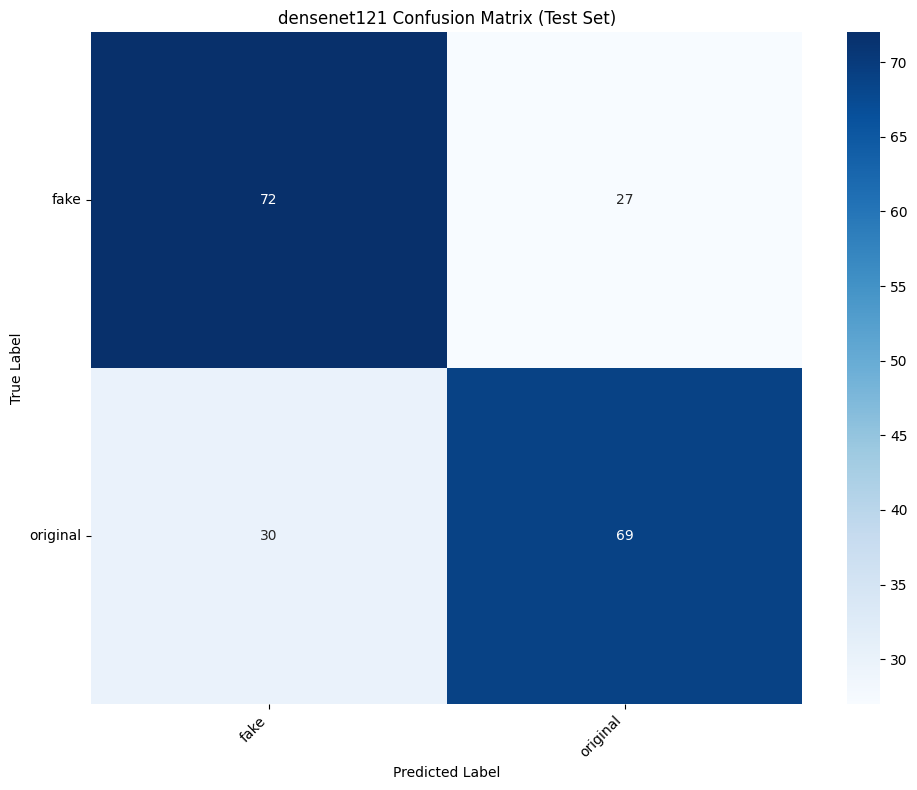

Saved confusion matrix plot for densenet121 to: /content/drive/MyDrive/model_logs/densenet121_test_confusion_matrix.png

RESNET50 CONFUSION MATRIX:
[[76 23]
 [33 66]]


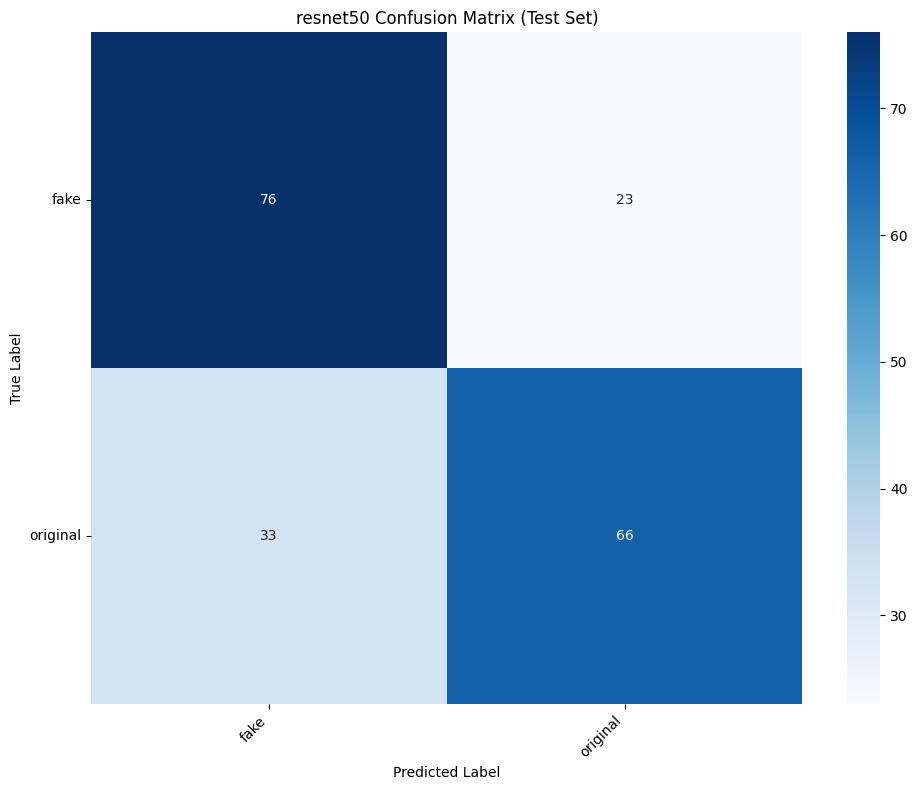

Saved confusion matrix plot for resnet50 to: /content/drive/MyDrive/model_logs/resnet50_test_confusion_matrix.png

EFFICIENTNET_B0 CONFUSION MATRIX:
[[60 39]
 [29 70]]


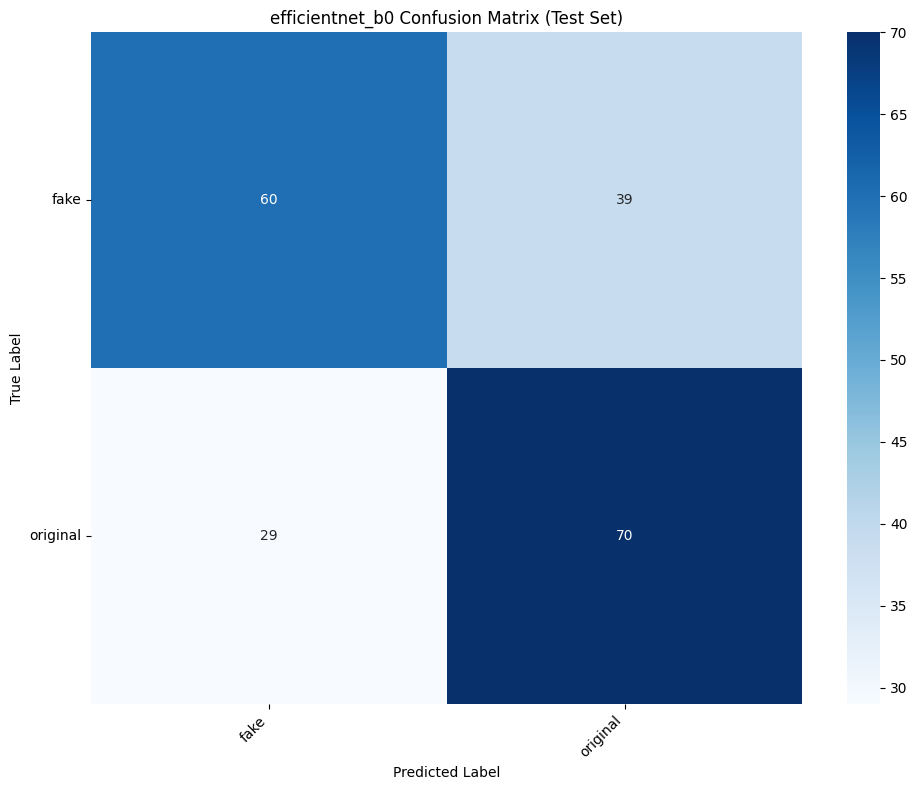

Saved confusion matrix plot for efficientnet_b0 to: /content/drive/MyDrive/model_logs/efficientnet_b0_test_confusion_matrix.png

STACKING CONFUSION MATRIX:
[[71 28]
 [29 70]]


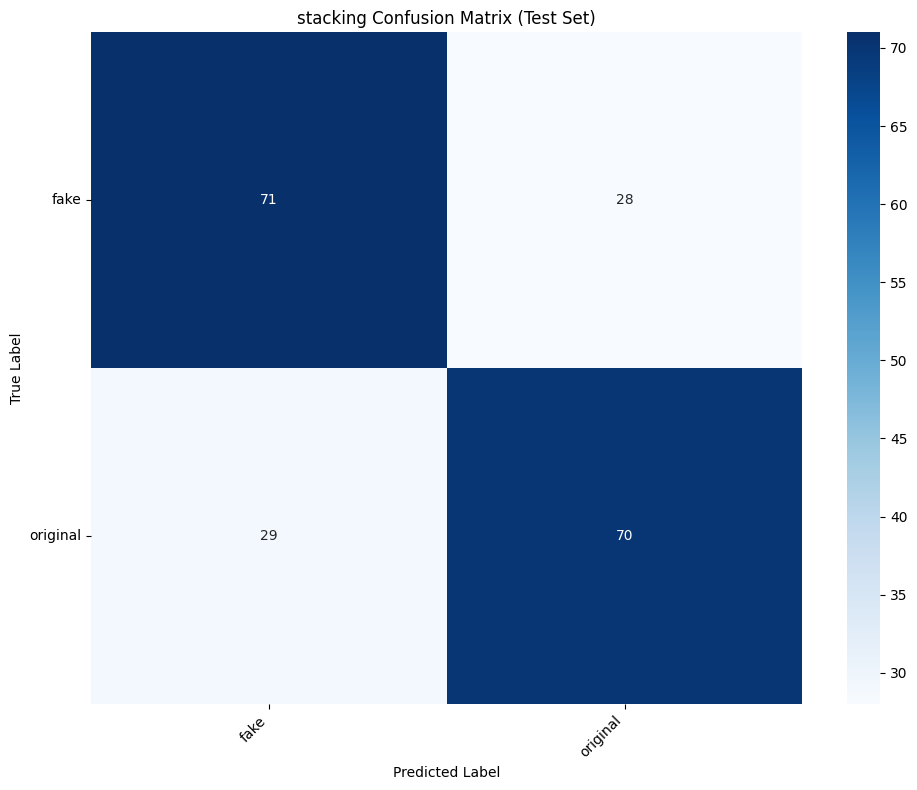

Saved confusion matrix plot for stacking to: /content/drive/MyDrive/model_logs/stacking_test_confusion_matrix.png

SOFT_VOTING CONFUSION MATRIX:
[[72 27]
 [32 67]]


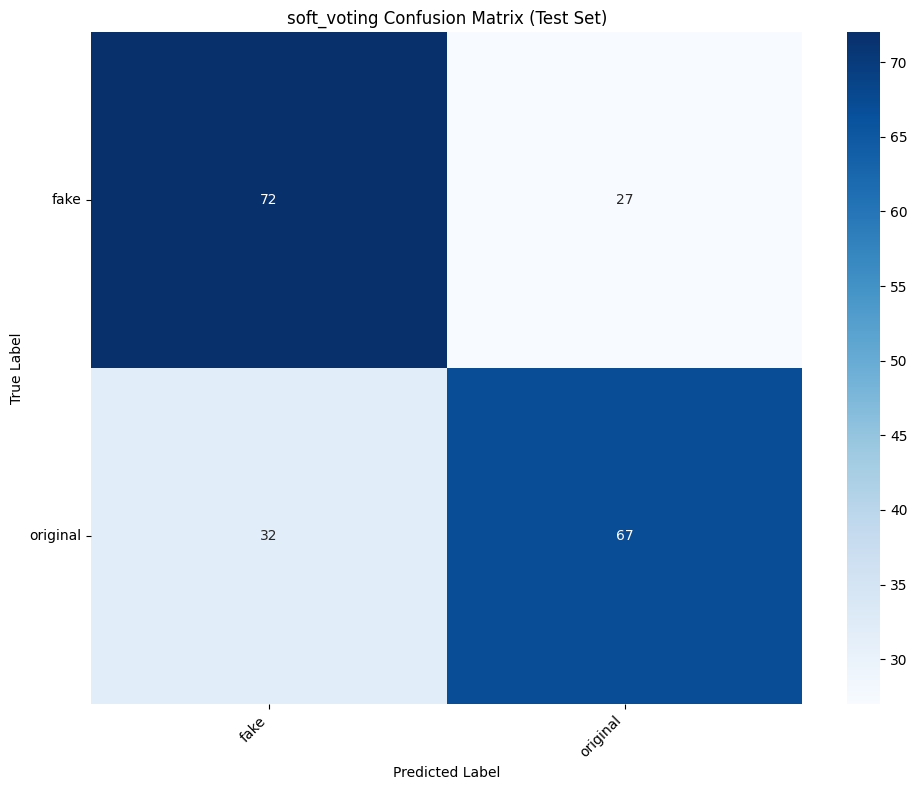

Saved confusion matrix plot for soft_voting to: /content/drive/MyDrive/model_logs/soft_voting_test_confusion_matrix.png


In [ ]:
# 📊 Print and visualize confusion matrices
print("\n--- Confusion Matrices (Test Set) ---")
if results:
    # Ensure models are plotted in a consistent order (intended models + stacking + soft_voting)
    # Include 'soft_voting' in the order
    model_order = list(best_hyperparameters.keys()) + ['stacking', 'soft_voting']
    for model_name in model_order:
        if model_name in results:
            # Skip if no confusion matrix data (e.g., evaluation failed for this model)
            if 'confusion_matrix' not in results[model_name]:
                print(f"No confusion matrix data for {model_name}. Skipping plot.")
                continue

            print(f"\n{model_name.upper()} CONFUSION MATRIX:")
            cm = results[model_name]['confusion_matrix']

            # Print raw confusion matrix
            print(cm)

            # Visualize confusion matrix
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
            plt.title(f'{model_name} Confusion Matrix (Test Set)')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
            plt.yticks(rotation=0) # Ensure y-axis labels are horizontal

            plt.tight_layout()
            plt.show() # Display the plot directly

            cm_filename = os.path.join(log_directory, f'{model_name}_test_confusion_matrix.png')
            plt.savefig(cm_filename) # Still save the plot to file
            plt.close() # Close the plot figure
            print(f"Saved confusion matrix plot for {model_name} to: {cm_filename}")
        else:
            print(f"\n{model_name.upper()} CONFUSION MATRIX: N/A (Evaluation skipped or failed)") # Improved message
else:
    print("No confusion matrices to plot.")

In [ ]:
# 📝 Print classification reports
print("\n--- Classification Reports (Test Set) ---")
if results:
    # Ensure models are reported in a consistent order (intended models + stacking + soft_voting)
    # Include 'soft_voting' in the order
    model_order = list(best_hyperparameters.keys()) + ['stacking', 'soft_voting']
    for model_name in model_order:
        if model_name in results:
            # Skip if no report data (e.g., evaluation failed for this model)
            if 'report' not in results[model_name]:
                print(f"No classification report data for {model_name}. Skipping print.")
                continue

            print(f"\n{model_name.upper()} CLASSIFICATION REPORT (Test Set):")
            report = results[model_name]['report']

            # Convert dictionary to DataFrame for better visualization
            report_df = pd.DataFrame(report).transpose()
            # Format the DataFrame
            report_df = report_df.round(4)
            print(report_df)

            # Save the report to CSV
            report_filename = os.path.join(log_directory, f'{model_name}_test_classification_report.csv')
            report_df.to_csv(report_filename)
            print(f"Saved classification report for {model_name} to: {report_filename}")
        else:
            print(f"\n{model_name.upper()} CLASSIFICATION REPORT (Test Set): N/A (Evaluation skipped or failed)") # Improved message

else:
    print("No classification reports to display.")


--- Classification Reports (Test Set) ---

DENSENET121 CLASSIFICATION REPORT (Test Set):
              precision  recall  f1-score   support
fake             0.7059  0.7273    0.7164   99.0000
original         0.7188  0.6970    0.7077   99.0000
accuracy         0.7121  0.7121    0.7121    0.7121
macro avg        0.7123  0.7121    0.7121  198.0000
weighted avg     0.7123  0.7121    0.7121  198.0000
Saved classification report for densenet121 to: /content/drive/MyDrive/model_logs/densenet121_test_classification_report.csv

RESNET50 CLASSIFICATION REPORT (Test Set):
              precision  recall  f1-score   support
fake             0.6972  0.7677    0.7308   99.0000
original         0.7416  0.6667    0.7021   99.0000
accuracy         0.7172  0.7172    0.7172    0.7172
macro avg        0.7194  0.7172    0.7164  198.0000
weighted avg     0.7194  0.7172    0.7164  198.0000
Saved classification report for resnet50 to: /content/drive/MyDrive/model_logs/resnet50_test_classification_report.cs


--- Generating Comparison Plots ---


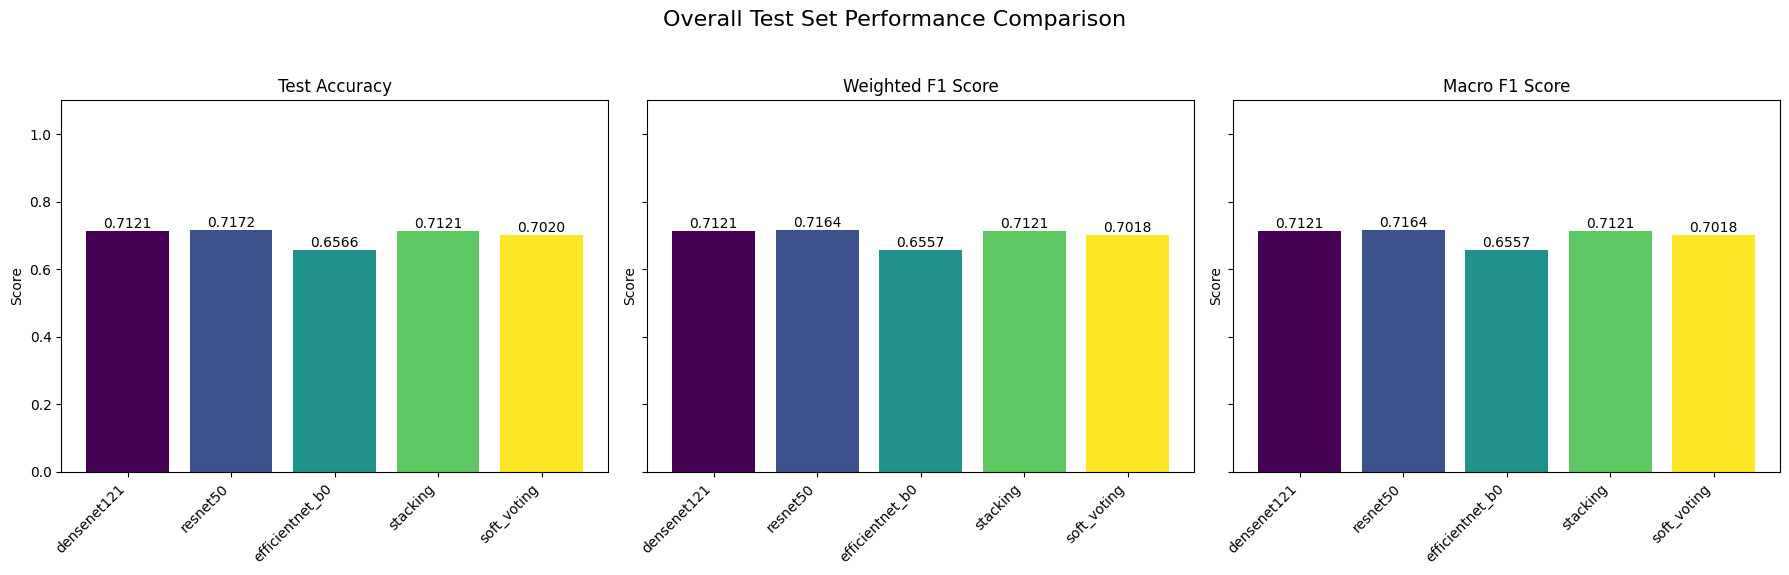

Saved overall performance comparison plot to: /content/drive/MyDrive/model_logs/overall_performance_comparison.png

Generating class-wise performance comparison plots...
  - Plotting metrics for class: fake


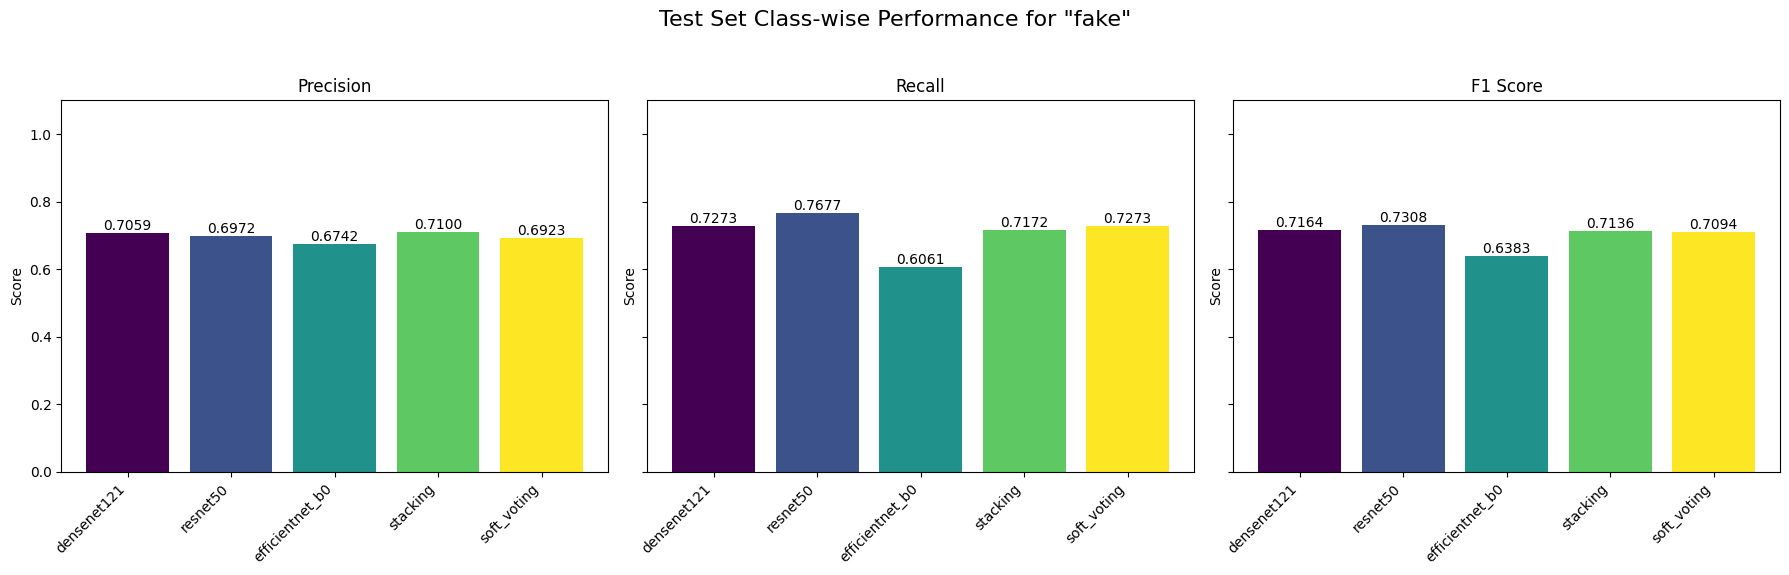

  - Saved class-wise performance plot for fake to: /content/drive/MyDrive/model_logs/class_fake_performance_comparison.png
  - Plotting metrics for class: original


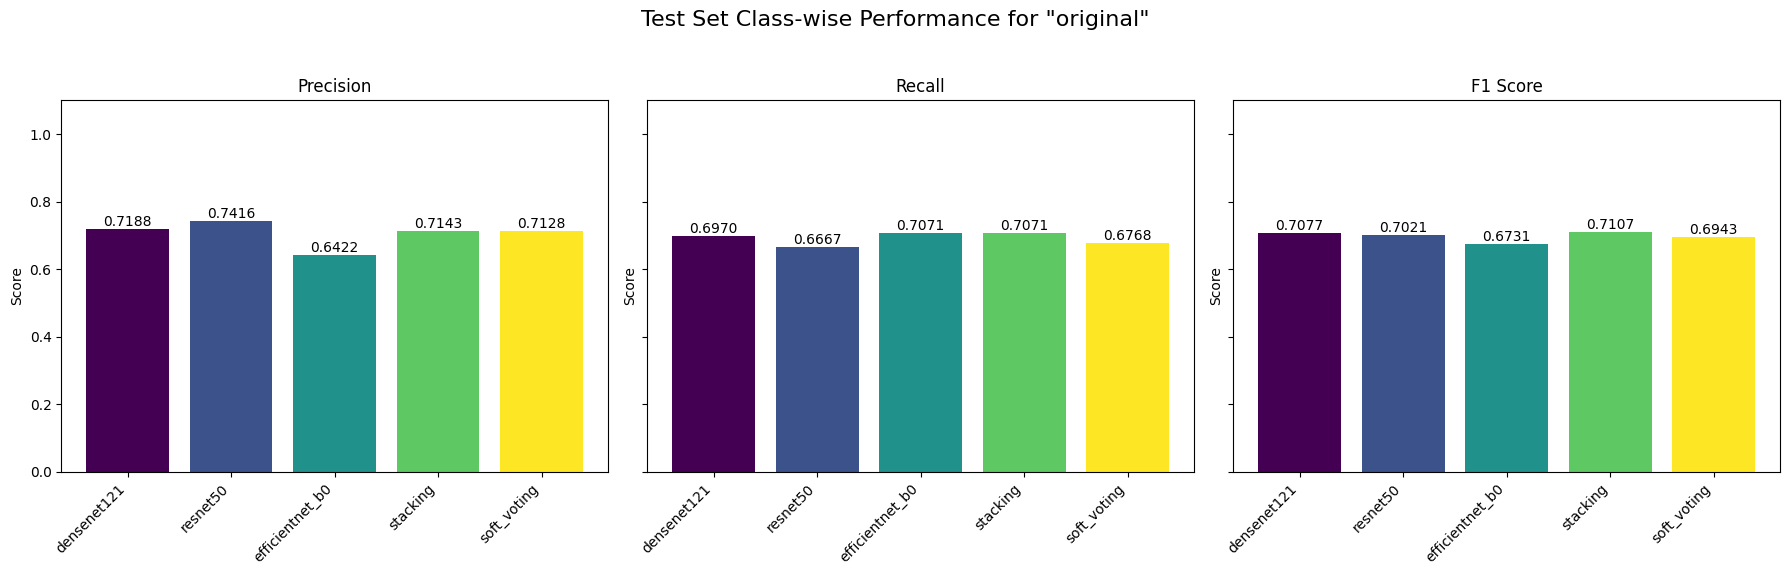

  - Saved class-wise performance plot for original to: /content/drive/MyDrive/model_logs/class_original_performance_comparison.png


In [ ]:
# 📊 Generate Comparison Plots (Overall and Class-wise)
print("\n--- Generating Comparison Plots ---")

# Only generate if there are results to compare
if results:
    metrics_to_plot = ['accuracy', 'f1_weighted', 'f1_macro']
    metric_titles = ['Test Accuracy', 'Weighted F1 Score', 'Macro F1 Score']

    # Define the order for overall plot comparison
    # Include 'soft_voting' in the order
    overall_plot_order = list(best_hyperparameters.keys()) + ['stacking', 'soft_voting']
    # Filter to include only models that were actually evaluated and exist in results
    overall_plot_models = [name for name in overall_plot_order if name in results]

    # Extract the metrics for evaluated models in the specified order
    plot_data = {metric: [results[name].get(metric, 0) for name in overall_plot_models] for metric in metrics_to_plot}

    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 6), sharey=True)
    fig.suptitle('Overall Test Set Performance Comparison', fontsize=16)

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        # Use overall_plot_models for the x-axis labels and data
        bars = ax.bar(overall_plot_models, plot_data[metric], color=plt.cm.viridis(np.linspace(0, 1, len(overall_plot_models))))
        ax.set_title(metric_titles[i])
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1.1) # Adjusted ylim slightly to make space for text labels above 1.0 if needed
        # Use tick_params for rotation
        ax.tick_params(axis='x', rotation=45)
        # Use setp for horizontal alignment of tick labels
        plt.setp(ax.get_xticklabels(), ha='right') # Set horizontal alignment

        # Add value labels on top of bars
        for bar in bars:
            yval = bar.get_height()
            # Ensure yval is a number before formatting
            if isinstance(yval, (int, float)):
                 ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', va='bottom', ha='center') # va: vertical alignment
            else:
                 ax.text(bar.get_x() + bar.get_width()/2.0, yval, str(yval), va='bottom', ha='center') # Print as string if not number


    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show() # Display the plot directly

    comparison_plot_filename = os.path.join(log_directory, 'overall_performance_comparison.png')
    plt.savefig(comparison_plot_filename) # Still save the plot to file
    plt.close() # Close the plot figure
    print(f"Saved overall performance comparison plot to: {comparison_plot_filename}")
else:
    print("No results available for overall performance plot.")


# 2. Class-wise Performance Comparison Bar Charts (Precision, Recall, F1 per class)
print("\nGenerating class-wise performance comparison plots...")

# Only generate if there are results and class names
if results and class_names:
    class_metrics_to_plot = ['precision', 'recall', 'f1-score']
    class_metric_titles = ['Precision', 'Recall', 'F1 Score']

    # Define the order for class-wise plot comparison
    # Include 'soft_voting' in the order
    class_plot_order = list(best_hyperparameters.keys()) + ['stacking', 'soft_voting']
    # Filter to include only models that were actually evaluated and exist in results
    class_plot_models = [name for name in class_plot_order if name in results]


    for class_idx, class_name in enumerate(class_names):
        print(f"  - Plotting metrics for class: {class_name}")
        fig, axes = plt.subplots(1, len(class_metrics_to_plot), figsize=(18, 6), sharey=True)
        fig.suptitle(f'Test Set Class-wise Performance for "{class_name}"', fontsize=16)

        for i, metric in enumerate(class_metrics_to_plot):
            ax = axes[i]
            class_scores = []
            # Iterate through evaluated model names for consistency in the specified order
            for model_name in class_plot_models:
                # Get metric score for the specific class from the report dictionary
                # Use .get() defensively
                class_report = results.get(model_name, {}).get('report', {})
                # Access metric for the specific class name, defaulting to 0 or N/A
                score_entry = class_report.get(class_name, {})
                score = score_entry.get(metric, 0) # Default to 0 if metric missing for class/model
                class_scores.append(score)


            # Use class_plot_models for the x-axis labels and data
            bars = ax.bar(class_plot_models, class_scores, color=plt.cm.viridis(np.linspace(0, 1, len(class_plot_models))))
            ax.set_title(class_metric_titles[i])
            ax.set_ylabel('Score')
            ax.set_ylim(0, 1.1) # Adjusted ylim slightly
            # Use tick_params for rotation
            ax.tick_params(axis='x', rotation=45)
            # Use setp for horizontal alignment of tick labels
            plt.setp(ax.get_xticklabels(), ha='right') # Set horizontal alignment


            # Add value labels on top of bars
            for bar in bars:
                yval = bar.get_height()
                # Ensure yval is a number before formatting
                if isinstance(yval, (int, float)):
                    ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', va='bottom', ha='center')
                else:
                     ax.text(bar.get_x() + bar.get_width()/2.0, yval, str(yval), va='bottom', ha='center')


        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show() # Display the plot directly

        class_plot_filename = os.path.join(log_directory, f'class_{class_name}_performance_comparison.png')
        plt.savefig(class_plot_filename) # Still save the plot to file
        plt.close() # Close the plot figure
        print(f"  - Saved class-wise performance plot for {class_name} to: {class_plot_filename}")

else:
    print("No results or class names available for class-wise performance plots.")

#FINAL RESNET



In [ ]:
# 📦 Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split # Used for stratified split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import os
import random # For setting seed

# Ensure reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 🔧 Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 🔁 Transformations
# Using the same transformations as your original ensemble code for consistency
transform = transforms.Compose([
    transforms.Resize((224, 224)), # ResNet50 typically uses 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

# 🧾 Custom dataset with RGB conversion
# Using the same UnifiedDataset as your original ensemble code
class UnifiedDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        path = self.image_paths[index]
        label = self.labels[index]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


# 📂 Load dataset paths and labels
dataset_path = "/content/drive/MyDrive/image" # Make sure this path is correct
full_dataset_info = ImageFolder(root=dataset_path)
image_paths = [item[0] for item in full_dataset_info.samples]
labels = [item[1] for item in full_dataset_info.samples]
class_names = full_dataset_info.classes
num_classes = len(class_names)

print(f"Found {len(image_paths)} images with {num_classes} classes: {class_names}")
print(f"Overall Class distribution: {Counter(labels)}")

# Stratified Data Splitting (80/20 train+val/test, then 80/20 train/val)
# Using the same splitting logic as your original ensemble code
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.20, stratify=labels, random_state=42
)

# Split the 80% train+val data into 80% train and 20% val
# This results in a 64% train, 16% val split of the original dataset
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.20, stratify=train_val_labels, random_state=42
)

# Create UnifiedDataset instances
train_dataset = UnifiedDataset(train_paths, train_labels, transform=transform)
val_dataset = UnifiedDataset(val_paths, val_labels, transform=transform)
test_dataset = UnifiedDataset(test_paths, test_labels, transform=transform)


print(f"Total: {len(image_paths)}, Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Train class distribution: {Counter(train_labels)}")
print(f"Val class distribution: {Counter(val_labels)}")
print(f"Test class distribution: {Counter(test_labels)}")


# ⚖️ Compute class weights for weighted loss (based on training data)
train_label_counter = Counter(train_labels)
class_weights = [len(train_dataset) / (num_classes * train_label_counter.get(c, 1e-9)) for c in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class weights (based on training data): {class_weights}")


# 🏗️ Load ResNet model
# Using ResNet50 as requested
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1) # Use weights for pretrained

# Modify the final layer for dataset
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# Move to device
model = model.to(device)

print("ResNet50 model loaded and modified.")

# 🔧 Best hyperparameters from previous ensemble code
# Using the best parameters found for ResNet50 in your ensemble script
best_hyperparameters = {
    'batch_size': 83,
    'lr': 0.0001645,
    'weight_decay': 0.0001644,
}

print(f"\nUsing best hyperparameters for ResNet50: {best_hyperparameters}")

# Create DataLoaders with best batch size
train_loader = DataLoader(train_dataset, batch_size=best_hyperparameters['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) # Val batch size can be fixed
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # Test batch size can be fixed


# Define optimizer and criterion
optimizer = optim.Adam(model.parameters(), lr=best_hyperparameters['lr'], weight_decay=best_hyperparameters['weight_decay'])
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

# 🚀 Training loop with validation and saving
num_epochs = 30 # Increased epochs for potentially better training (adjust as needed)
save_dir = '/content/drive/MyDrive/trained_single_model' # Directory to save the model
os.makedirs(save_dir, exist_ok=True)
model_save_path = os.path.join(save_dir, 'resnet50_best_single_model.pth')

best_val_accuracy = 0.0
print(f"\nStarting training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # --- Validation Phase ---
    model.eval()
    correct_val = 0
    total_val = 0
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # --- Save best model based on validation accuracy ---
    if epoch_val_acc > best_val_accuracy:
        best_val_accuracy = epoch_val_acc
        print(f"Validation accuracy improved. Saving model to {model_save_path}")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_val_loss,
            'val_accuracy': best_val_accuracy,
            'class_names': class_names,
            'hyperparameters': best_hyperparameters
        }, model_save_path)


print(f"\nFinished Training. Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best model saved to: {model_save_path}")


# 🧐 Final Evaluation on Test Set using the best saved model
print("\n--- Evaluating the Best Saved Model on Test Set ---")

# Load the best saved model
if os.path.exists(model_save_path):
    checkpoint = torch.load(model_save_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model checkpoint from epoch {checkpoint['epoch']} with Val Acc: {checkpoint['val_accuracy']:.4f}")
else:
    print(f"Error: Best model not found at {model_save_path}. Cannot perform test evaluation.")
    # You might want to exit or handle this case appropriately
    exit() # Exit if the best model couldn't be loaded

# Set model to evaluation mode
model.eval()

# Run evaluation on the test set
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert lists to numpy arrays for metrics
all_preds_np = np.array(all_preds)
all_labels_np = np.array(all_labels)

# Calculate and print metrics
print("\nTest Set Evaluation Metrics:")
test_accuracy = accuracy_score(all_labels_np, all_preds_np)
test_f1_weighted = f1_score(all_labels_np, all_preds_np, average='weighted', zero_division=0)
test_f1_macro = f1_score(all_labels_np, all_preds_np, average='macro', zero_division=0)
test_cm = confusion_matrix(all_labels_np, all_preds_np)
test_report = classification_report(all_labels_np, all_preds_np, target_names=class_names, zero_division=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Weighted F1 Score: {test_f1_weighted:.4f}")
print(f"Test Macro F1 Score: {test_f1_macro:.4f}")
print("\nConfusion Matrix:\n", test_cm)
print("\nClassification Report:\n", test_report)



Using device: cuda
Found 990 images with 2 classes: ['fake', 'original']
Overall Class distribution: Counter({0: 495, 1: 495})
Total: 990, Train: 633, Val: 159, Test: 198
Train class distribution: Counter({1: 317, 0: 316})
Val class distribution: Counter({0: 80, 1: 79})
Test class distribution: Counter({0: 99, 1: 99})
Class weights (based on training data): [1.0015822784810127, 0.998422712933754]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


ResNet50 model loaded and modified.

Using best hyperparameters for ResNet50: {'batch_size': 83, 'lr': 0.0001645, 'weight_decay': 0.0001644}

Starting training for 30 epochs...
Epoch 1/30, Train Loss: 0.7409, Train Acc: 0.5150, Val Loss: 0.8626, Val Acc: 0.4906
Validation accuracy improved. Saving model to /content/drive/MyDrive/trained_single_model/resnet50_best_single_model.pth
Epoch 2/30, Train Loss: 0.5605, Train Acc: 0.7141, Val Loss: 0.9249, Val Acc: 0.5031
Validation accuracy improved. Saving model to /content/drive/MyDrive/trained_single_model/resnet50_best_single_model.pth
Epoch 3/30, Train Loss: 0.3191, Train Acc: 0.8736, Val Loss: 1.0008, Val Acc: 0.6038
Validation accuracy improved. Saving model to /content/drive/MyDrive/trained_single_model/resnet50_best_single_model.pth
Epoch 4/30, Train Loss: 0.1838, Train Acc: 0.9305, Val Loss: 1.0527, Val Acc: 0.6667
Validation accuracy improved. Saving model to /content/drive/MyDrive/trained_single_model/resnet50_best_single_model.pth